# Notebook 02 — Preprocessing & Augmentation Pipeline
### Anti-UAV Drone Detection | AI447 Computer Vision

**Purpose:** Verify the preprocessing and augmentation pipeline before training. This notebook:
1. Validates all images in the merged pool (size, format, label consistency)
2. Visualises the augmentation pipeline with before/after comparisons
3. Computes normalisation statistics (mean/std per channel) for the dataset
4. Exports a summary to MLflow and `reports/figures/`

**Run after:** `01_EDA_and_DataPrep.ipynb`

## 0 · Setup

In [3]:
import random
import sys
import warnings
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from albumentations.pytorch import ToTensorV2
from PIL import Image
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT    = PROJECT_ROOT / 'data'
REPORTS_DIR  = PROJECT_ROOT / 'reports'
FIGURES_DIR  = REPORTS_DIR  / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MERGED_IMG = DATA_ROOT / 'merged' / 'images'
MERGED_LBL = DATA_ROOT / 'merged' / 'labels'

# Change these lines to use a relative path
MLFLOW_URI = "file:mlruns" 
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment('data-preparation')
IMG_EXTS = {'.jpg', '.jpeg', '.png'}
print('Setup complete ✓')

Setup complete ✓


---
## 1 · Image Validation

Check every image in the merged pool for corruption, wrong format, missing labels.

In [4]:
def validate_dataset(img_dir: Path, lbl_dir: Path, max_check: int = 5000):
    """
    Validate all images and labels.
    Returns (ok_list, error_list) where each element is a dict.
    """
    images = sorted(p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS)
    if len(images) > max_check:
        images = random.sample(images, max_check)

    ok_list    = []
    error_list = []

    for img_path in tqdm(images, desc='Validating images'):
        errors = []

        # 1. Can PIL open it?
        try:
            img = Image.open(img_path)
            w, h = img.size
            if img.mode not in ('RGB', 'L', 'RGBA'):
                errors.append(f'Unusual mode: {img.mode}')
        except Exception as e:
            errors.append(f'Corrupt image: {e}')
            error_list.append({'path': str(img_path), 'errors': errors})
            continue

        # 2. Minimum size check
        if w < 32 or h < 32:
            errors.append(f'Too small: {w}×{h}')

        # 3. Label file exists?
        lbl_path = lbl_dir / f'{img_path.stem}.txt'
        if not lbl_path.exists():
            errors.append('Missing label file')
        else:
            # 4. Label format valid?
            for line_no, line in enumerate(lbl_path.read_text().splitlines(), 1):
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) != 5:
                    errors.append(f'Label line {line_no}: expected 5 values, got {len(parts)}')
                    break
                try:
                    cls_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:])
                    if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 < bw <= 1 and 0 < bh <= 1):
                        errors.append(f'Label line {line_no}: values out of [0,1] range')
                except ValueError as e:
                    errors.append(f'Label line {line_no}: parse error {e}')

        record = {'path': str(img_path), 'width': w, 'height': h, 'errors': errors}
        if errors:
            error_list.append(record)
        else:
            ok_list.append(record)

    return ok_list, error_list


if MERGED_IMG.exists():
    ok, errors = validate_dataset(MERGED_IMG, MERGED_LBL)
    print(f'\n✅ Valid images: {len(ok):,}')
    print(f'❌ Errors found: {len(errors):,}')
    if errors:
        print('\nFirst 5 errors:')
        for e in errors[:5]:
            print(f'  {Path(e["path"]).name}: {e["errors"]}')
else:
    print('Merged pool not found — run Notebook 01 first.')
    ok, errors = [], []

Validating images:   0%|          | 0/5000 [00:00<?, ?it/s]


✅ Valid images: 5,000
❌ Errors found: 0


---
## 2 · Channel Statistics (Normalisation)

Compute per-channel mean and standard deviation across the training set.
These values are used to normalise inputs — Ultralytics uses ImageNet defaults
but computing dataset-specific stats is good practice for the report.

In [5]:
def compute_channel_stats(img_dir: Path, n_sample: int = 1000, seed: int = SEED):
    """
    Estimate per-channel (R, G, B) mean and std from a random sample.
    Returns (mean_rgb, std_rgb) both as numpy arrays of shape (3,).
    """
    all_imgs = sorted(p for p in img_dir.rglob('*') if p.suffix.lower() in IMG_EXTS)
    rng = random.Random(seed)
    sample = rng.sample(all_imgs, min(n_sample, len(all_imgs)))

    pixel_sums   = np.zeros(3, dtype=np.float64)
    pixel_sq_sum = np.zeros(3, dtype=np.float64)
    n_pixels     = 0

    for img_path in tqdm(sample, desc='Computing channel stats'):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        img = img.astype(np.float64) / 255.0
        H, W = img.shape[:2]
        pixel_sums   += img.reshape(-1, 3).sum(axis=0)
        pixel_sq_sum += (img ** 2).reshape(-1, 3).sum(axis=0)
        n_pixels     += H * W

    mean = pixel_sums   / n_pixels
    std  = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)
    return mean, std


if MERGED_IMG.exists():
    print('Computing channel statistics (sampled from 1000 images)...')
    mean_rgb, std_rgb = compute_channel_stats(MERGED_IMG)

    print(f'\nDataset channel statistics (values in [0,1]):')
    print(f'  Mean  R={mean_rgb[0]:.4f}  G={mean_rgb[1]:.4f}  B={mean_rgb[2]:.4f}')
    print(f'  Std   R={std_rgb[0]:.4f}  G={std_rgb[1]:.4f}  B={std_rgb[2]:.4f}')
    print()
    print('ImageNet defaults (for comparison):')
    print('  Mean  R=0.485  G=0.456  B=0.406')
    print('  Std   R=0.229  G=0.224  B=0.225')
    print()
    print('Note: Ultralytics normalises with ImageNet stats by default.')
    print('The dataset-specific values above are documented in the report')
    print('to justify this choice (or deviation from it).')
else:
    mean_rgb = np.array([0.485, 0.456, 0.406])
    std_rgb  = np.array([0.229, 0.224, 0.225])
    print('Using ImageNet defaults (merged pool not found).')

Computing channel statistics (sampled from 1000 images)...


Computing channel stats:   0%|          | 0/1000 [00:00<?, ?it/s]


Dataset channel statistics (values in [0,1]):
  Mean  R=0.4397  G=0.4760  B=0.5105
  Std   R=0.2760  G=0.2881  B=0.3211

ImageNet defaults (for comparison):
  Mean  R=0.485  G=0.456  B=0.406
  Std   R=0.229  G=0.224  B=0.225

Note: Ultralytics normalises with ImageNet stats by default.
The dataset-specific values above are documented in the report
to justify this choice (or deviation from it).


---
## 3 · Augmentation Pipeline Visualisation

Show the exact augmentations applied during training and their effect on drone images.
The three HP combos use different augmentation settings — we visualise all of them.

In [6]:
# ── Define augmentation pipelines matching the 3 HP combos ───────────────

def build_augmentation_pipeline(mosaic: bool, mixup: bool, imgsz: int = 640):
    """
    Albumentations pipeline mirroring Ultralytics augmentation.
    Note: Mosaic and Mixup are implemented inside Ultralytics at the
    dataset level (not per-image). We show per-image augmentations here.
    """
    transforms = [
        # Geometric
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.1, scale_limit=0.5, rotate_limit=0,
            border_mode=cv2.BORDER_CONSTANT, value=114, p=0.5,
        ),
        # Colour / photometric
        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=35, val_shift_limit=20, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussianBlur(blur_limit=(3, 7), p=0.1),
        A.GaussNoise(var_limit=(5, 30), p=0.1),
        # Resize to training size
        A.LongestMaxSize(max_size=imgsz),
        A.PadIfNeeded(
            min_height=imgsz, min_width=imgsz,
            border_mode=cv2.BORDER_CONSTANT, value=114,
        ),
    ]
    if mixup:
        # Random erasing simulates mixup-style masking for visualisation
        transforms.append(A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.2))

    return A.Compose(
        transforms,
        bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']),
    )


HP_PIPELINES = {
    'HP1 — Baseline (SGD, std aug)':    build_augmentation_pipeline(mosaic=True, mixup=False, imgsz=640),
    'HP2 — Best (AdamW, +Mixup)':       build_augmentation_pipeline(mosaic=True, mixup=True,  imgsz=640),
    'HP3 — High-res (AdamW, 1280px)':   build_augmentation_pipeline(mosaic=True, mixup=True,  imgsz=1280),
}
print('Augmentation pipelines defined.')

Augmentation pipelines defined.


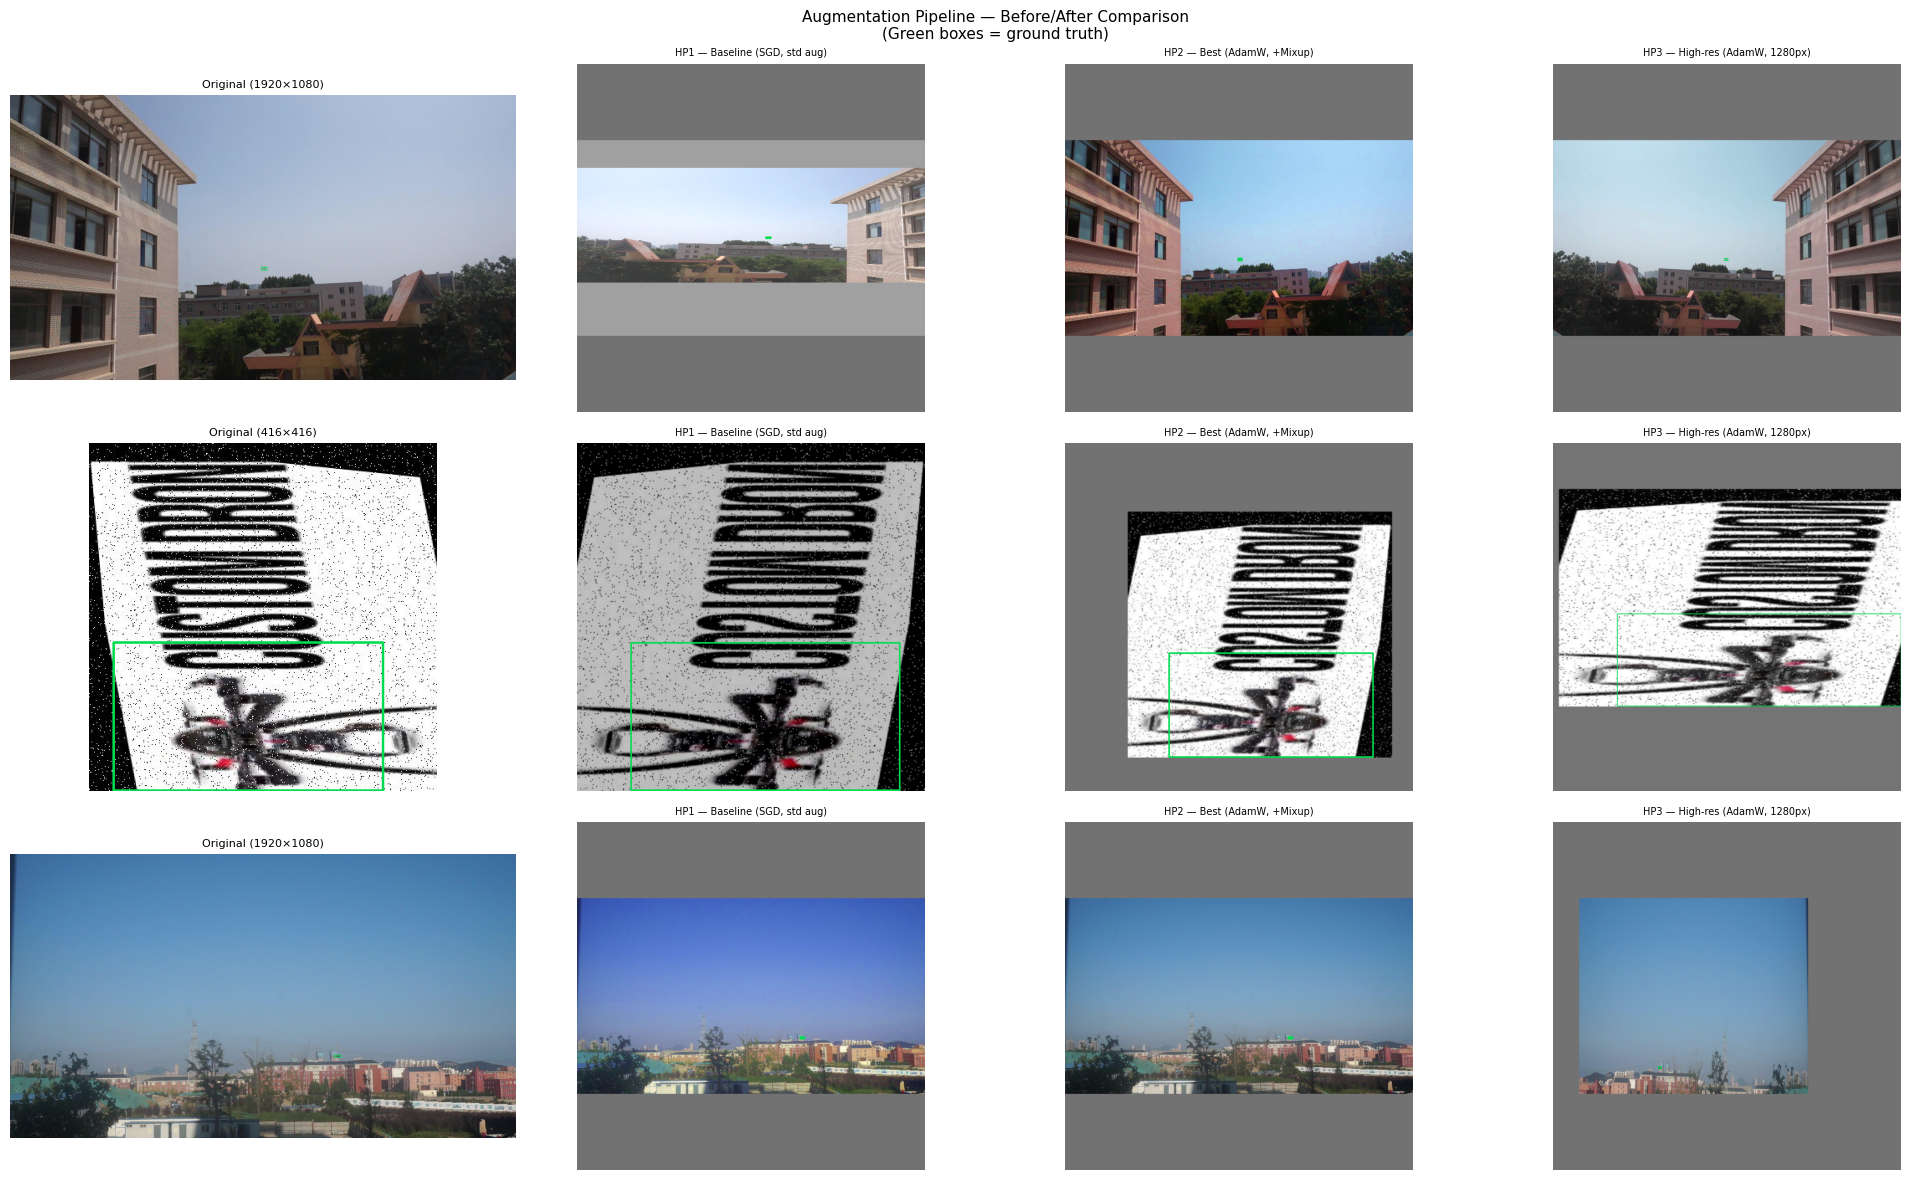

Saved -> c:\Users\aljaf\uav_detection\reports\figures/fig9_augmentation_pipeline.png


In [7]:
def load_random_positive(img_dir: Path, lbl_dir: Path, seed: int = SEED):
    """Load a random image+label pair that contains at least one annotation."""
    rng = random.Random(seed)
    imgs = sorted(p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS)
    rng.shuffle(imgs)
    for p in imgs:
        lbl = lbl_dir / f'{p.stem}.txt'
        if lbl.exists() and lbl.read_text().strip():
            img_bgr = cv2.imread(str(p))
            if img_bgr is None:
                continue
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            # Parse YOLO labels
            boxes, labels = [], []
            for line in lbl.read_text().splitlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    labels.append(int(parts[0]))
                    boxes.append(list(map(float, parts[1:])))
            return img_rgb, boxes, labels, p.name
    return None, [], [], ''


def draw_yolo_on_rgb(img_rgb, boxes, color=(0, 220, 80)):
    """Draw YOLO bboxes on an RGB numpy array."""
    out = img_rgb.copy()
    H, W = out.shape[:2]
    for cx, cy, bw, bh in boxes:
        x1 = int((cx - bw/2) * W)
        y1 = int((cy - bh/2) * H)
        x2 = int((cx + bw/2) * W)
        y2 = int((cy + bh/2) * H)
        cv2.rectangle(out, (x1,y1), (x2,y2), color, 2)
    return out


# Pick a source image directory to sample from
src_img = MERGED_IMG if MERGED_IMG.exists() else (
    DATA_ROOT / 'raw' / 'dut_anti_uav' / 'DUT-Anti-UAV-Detection' / 'train' / 'images'
)
src_lbl = MERGED_LBL if MERGED_LBL.exists() else (
    DATA_ROOT / 'raw' / 'dut_anti_uav' / 'DUT-Anti-UAV-Detection' / 'train' / 'labels'
)

if src_img.exists():
    # Show augmentations for 3 different source images across all 3 HP pipelines
    n_imgs = 3
    fig, axes = plt.subplots(n_imgs, len(HP_PIPELINES) + 1,
                             figsize=(5 * (len(HP_PIPELINES) + 1), 4 * n_imgs))

    for row, seed_offset in enumerate(range(n_imgs)):
        img_rgb, boxes, labels, fname = load_random_positive(src_img, src_lbl, seed=SEED+seed_offset*7)
        if img_rgb is None:
            continue

        # Original image
        ax = axes[row, 0]
        ax.imshow(draw_yolo_on_rgb(img_rgb, boxes))
        ax.set_title(f'Original ({img_rgb.shape[1]}×{img_rgb.shape[0]})', fontsize=8)
        ax.axis('off')

        # Augmented with each pipeline
        for col, (hp_name, pipeline) in enumerate(HP_PIPELINES.items(), 1):
            try:
                aug = pipeline(image=img_rgb, bboxes=boxes, class_labels=labels)
                aug_img   = aug['image']
                aug_boxes = aug['bboxes']
                ax = axes[row, col]
                ax.imshow(draw_yolo_on_rgb(aug_img, aug_boxes))
                ax.set_title(hp_name, fontsize=7)
                ax.axis('off')
            except Exception as e:
                axes[row, col].set_title(f'Error: {e}', fontsize=7)
                axes[row, col].axis('off')

    plt.suptitle('Augmentation Pipeline — Before/After Comparison\n(Green boxes = ground truth)', fontsize=11)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig9_augmentation_pipeline.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {FIGURES_DIR}/fig9_augmentation_pipeline.png')
else:
    print('Image directory not found — download dataset first.')

---
## 4 · Augmentation Intensity Analysis

Quantify how much augmentation changes each image (SSIM and pixel distance).

Measuring augmentation intensity for each HP pipeline...


Measuring augmentation:   0%|          | 0/50 [00:00<?, ?it/s]

  HP1 — Baseline (SGD, std aug): SSIM=0.537±0.253  L1=57.69


Measuring augmentation:   0%|          | 0/50 [00:00<?, ?it/s]

  HP2 — Best (AdamW, +Mixup): SSIM=0.533±0.263  L1=55.69


Measuring augmentation:   0%|          | 0/50 [00:00<?, ?it/s]

  HP3 — High-res (AdamW, 1280px): SSIM=0.450±0.266  L1=56.58


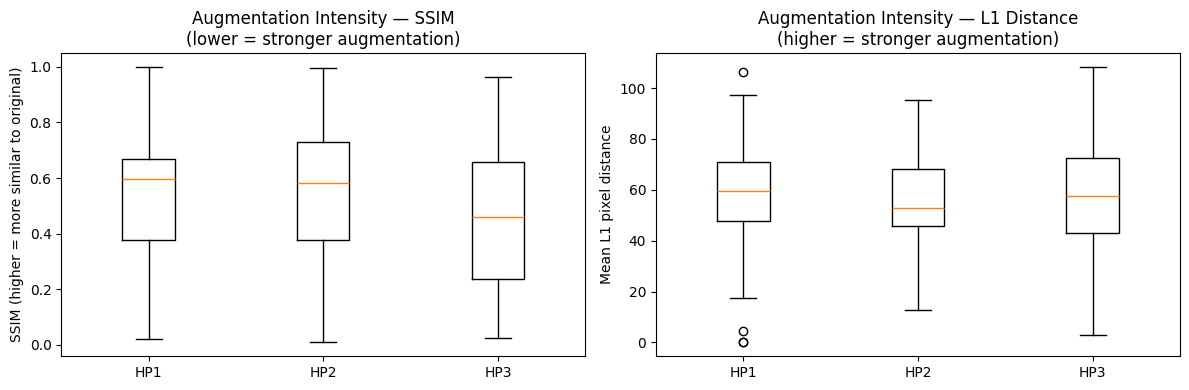

In [8]:
from skimage.metrics import structural_similarity as ssim  # scikit-image

def measure_augmentation_intensity(img_dir, lbl_dir, pipeline, n=100, seed=SEED):
    """Measure mean SSIM between original and augmented images."""
    rng = random.Random(seed)
    imgs = sorted(p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS)
    sample = rng.sample(imgs, min(n, len(imgs)))

    ssim_scores = []
    l1_distances = []

    for p in tqdm(sample, desc='Measuring augmentation', leave=False):
        lbl = lbl_dir / f'{p.stem}.txt'
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        boxes  = []
        labels = []
        if lbl.exists():
            for line in lbl.read_text().splitlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    labels.append(int(parts[0]))
                    boxes.append(list(map(float, parts[1:])))
        try:
            aug_result = pipeline(image=img, bboxes=boxes, class_labels=labels)
            aug_img = cv2.resize(aug_result['image'], (img.shape[1], img.shape[0]))
            s = ssim(img, aug_img, channel_axis=2)
            d = np.abs(img.astype(float) - aug_img.astype(float)).mean()
            ssim_scores.append(s)
            l1_distances.append(d)
        except Exception:
            pass

    return np.array(ssim_scores), np.array(l1_distances)

if src_img.exists():
    print('Measuring augmentation intensity for each HP pipeline...')
    aug_stats = {}
    for hp_name, pipeline in HP_PIPELINES.items():
        scores, dists = measure_augmentation_intensity(src_img, src_lbl, pipeline, n=50)
        aug_stats[hp_name] = {'ssim': scores, 'l1': dists}
        print(f'  {hp_name}: SSIM={scores.mean():.3f}±{scores.std():.3f}  L1={dists.mean():.2f}')

    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    names = list(aug_stats.keys())
    ssim_vals = [aug_stats[n]['ssim'] for n in names]
    l1_vals   = [aug_stats[n]['l1']   for n in names]

    axes[0].boxplot(ssim_vals, labels=[n.split('—')[0].strip() for n in names])
    axes[0].set_ylabel('SSIM (higher = more similar to original)')
    axes[0].set_title('Augmentation Intensity — SSIM\n(lower = stronger augmentation)')

    axes[1].boxplot(l1_vals, labels=[n.split('—')[0].strip() for n in names])
    axes[1].set_ylabel('Mean L1 pixel distance')
    axes[1].set_title('Augmentation Intensity — L1 Distance\n(higher = stronger augmentation)')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig10_augmentation_intensity.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 5 · Log Preprocessing Stats to MLflow

In [9]:
with mlflow.start_run(run_name='preprocessing-validation') as run:
    mlflow.log_params({
        'n_valid_images':   len(ok),
        'n_error_images':   len(errors),
        'imagenet_norm':    True,   # Ultralytics uses ImageNet by default
        'augmentation_hp1': 'SGD_mosaic',
        'augmentation_hp2': 'AdamW_mosaic_mixup',
        'augmentation_hp3': 'AdamW_mosaic_mixup_1280px',
    })

    mlflow.log_metrics({
        'dataset_mean_R': round(float(mean_rgb[0]), 4),
        'dataset_mean_G': round(float(mean_rgb[1]), 4),
        'dataset_mean_B': round(float(mean_rgb[2]), 4),
        'dataset_std_R':  round(float(std_rgb[0]),  4),
        'dataset_std_G':  round(float(std_rgb[1]),  4),
        'dataset_std_B':  round(float(std_rgb[2]),  4),
        'validation_error_rate': round(len(errors) / max(len(ok)+len(errors), 1), 4),
    })

    for fig_file in FIGURES_DIR.glob('fig9*.png'):
        mlflow.log_artifact(str(fig_file), 'preprocessing_figures')
    for fig_file in FIGURES_DIR.glob('fig10*.png'):
        mlflow.log_artifact(str(fig_file), 'preprocessing_figures')

    print(f'✅ MLflow run: {run.info.run_id}')
    print('\nNext → Open 03_YOLOv11_Training.ipynb to start training')

✅ MLflow run: d5ae4e1bc6ef4a9bab2bfeb179c72baf

Next → Open 03_YOLOv11_Training.ipynb to start training
